# PGD Step-Size Ablation — Answering Why PGD < FGSM

Reviewer #2 flagged that PGD appearing *less* damaging than FGSM is counterintuitive
and needs rigorous explanation. This notebook isolates the cause empirically.

**Hypothesis**: on z-score normalised tabular data, a small PGD step size α causes each
iterative step to be largely cancelled by L∞ projection back to the ε-ball, so PGD
under-exploits the perturbation budget. FGSM's single full-budget step in the
sign-gradient direction is more disruptive at small-to-moderate ε.

We test α ∈ {0.005, 0.01, 0.02, 0.05, 0.10} with fixed 10 steps, across both datasets.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, torch, torch.nn as nn, torch.optim as optim
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

EPSILONS = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
ALPHA_VALUES = [0.005, 0.01, 0.02, 0.05, 0.10]
PGD_STEPS = 10
DEVICE = "cpu"


In [11]:
# --- MLP definition (same architecture as base study) ---
class MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2))
    def forward(self, x): return self.net(x)

def train_mlp(Xtr, ytr, epochs=20, lr=0.001, seed=42):
    torch.manual_seed(seed)   # reproducible weights across runs
    model = MLP(Xtr.shape[1])
    Xt = torch.tensor(Xtr, dtype=torch.float32)
    yt = torch.tensor(ytr, dtype=torch.long)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        crit(model(Xt), yt).backward(); opt.step()
    return model

def mlp_acc(model, X, y):
    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(X, dtype=torch.float32)
        yt = torch.tensor(y, dtype=torch.long)
        return (model(Xt).argmax(1) == yt).float().mean().item()

In [12]:
# --- Attack implementations ---
criterion = nn.CrossEntropyLoss()

def fgsm(model, X, y, eps):
    Xt = torch.tensor(X, dtype=torch.float32).requires_grad_(True)
    yt = torch.tensor(y, dtype=torch.long)
    criterion(model(Xt), yt).backward()
    return (Xt + eps * Xt.grad.sign()).detach().numpy()

def pgd(model, X, y, eps, alpha, steps):
    X0 = torch.tensor(X, dtype=torch.float32)
    Xa = X0.clone().detach()
    yt = torch.tensor(y, dtype=torch.long)
    for _ in range(steps):
        Xa = Xa.clone().detach().requires_grad_(True)
        criterion(model(Xa), yt).backward()
        with torch.no_grad():
            # step then project back into L-inf ball around X0
            Xa = torch.clamp(
                X0 + torch.clamp(Xa + alpha * Xa.grad.sign() - X0, -eps, eps),
                -5, 5)
    return Xa.detach().numpy()

def ri(accs):
    eps = EPSILONS
    return round(float(np.trapezoid(accs, eps) / (eps[-1] - eps[0])), 4)


In [13]:
# --- Load and preprocess Phishing dataset ---
df = pd.read_csv("Phishing_Legitimate_full.csv")
target = "CLASS_LABEL" if "CLASS_LABEL" in df.columns else df.columns[-1]
Xp = df.drop(columns=[target]).select_dtypes(include=[np.number]).values.astype(np.float32)
yp = df[target].values.astype(int)
if yp.min() < 0: yp = (yp > 0).astype(int)

Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(Xp, yp, test_size=0.2,
                                                random_state=42, stratify=yp)
sc_p = StandardScaler().fit(Xp_tr)
Xp_tr, Xp_te = sc_p.transform(Xp_tr), sc_p.transform(Xp_te)

print(f"Phishing  train={Xp_tr.shape}  test={Xp_te.shape}")
mlp_p = train_mlp(Xp_tr, yp_tr)
print(f"  MLP clean acc: {mlp_acc(mlp_p, Xp_te, yp_te):.4f}")


Phishing  train=(8000, 49)  test=(2000, 49)
  MLP clean acc: 0.9360


In [14]:
# --- Load and preprocess UNSW-NB15 dataset ---
df2 = pd.read_csv("UNSW_NB15_training-set.csv")
drop_cols = ["id","attack_cat","label"] if "label" in df2.columns else []
target2 = "label" if "label" in df2.columns else df2.columns[-1]
Xu = df2.drop(columns=[c for c in drop_cols if c != target2 and c in df2.columns],
              errors="ignore").select_dtypes(include=[np.number]).values.astype(np.float32)
yu = df2[target2].values.astype(int)
if yu.min() < 0: yu = (yu > 0).astype(int)

Xu_tr, Xu_te, yu_tr, yu_te = train_test_split(Xu, yu, test_size=0.2,
                                                random_state=42, stratify=yu)
sc_u = StandardScaler().fit(Xu_tr)
Xu_tr, Xu_te = sc_u.transform(Xu_tr), sc_u.transform(Xu_te)

print(f"UNSW-NB15 train={Xu_tr.shape}  test={Xu_te.shape}")
mlp_u = train_mlp(Xu_tr, yu_tr)
print(f"  MLP clean acc: {mlp_acc(mlp_u, Xu_te, yu_te):.4f}")


UNSW-NB15 train=(65865, 40)  test=(16467, 40)
  MLP clean acc: 0.7979


In [15]:
# --- Run ablation: FGSM + PGD at each alpha, for both datasets ---
def run_ablation(model, Xte, yte, label):
    print(f"\n=== {label} ===")
    results = {}

    # FGSM baseline
    acc_f = [mlp_acc(model, fgsm(model, Xte, yte, e) if e > 0 else Xte, yte)
             for e in EPSILONS]
    results["FGSM"] = acc_f
    print(f"  FGSM          RI={ri(acc_f):.4f}")

    # PGD at each alpha
    for alpha in ALPHA_VALUES:
        acc_p = [mlp_acc(model, pgd(model, Xte, yte, e, alpha, PGD_STEPS) if e > 0 else Xte, yte)
                 for e in EPSILONS]
        key = f"PGD α={alpha}"
        results[key] = acc_p
        print(f"  PGD α={alpha:<5}    RI={ri(acc_p):.4f}")

    return results

results_p = run_ablation(mlp_p, Xp_te, yp_te, "Phishing")
results_u = run_ablation(mlp_u, Xu_te, yu_te, "UNSW-NB15")



=== Phishing ===
  FGSM          RI=0.6771
  PGD α=0.005    RI=0.8911
  PGD α=0.01     RI=0.8185
  PGD α=0.02     RI=0.6938
  PGD α=0.05     RI=0.6510
  PGD α=0.1      RI=0.6489

=== UNSW-NB15 ===
  FGSM          RI=0.7131
  PGD α=0.005    RI=0.7762
  PGD α=0.01     RI=0.7607
  PGD α=0.02     RI=0.7235
  PGD α=0.05     RI=0.6787
  PGD α=0.1      RI=0.6736


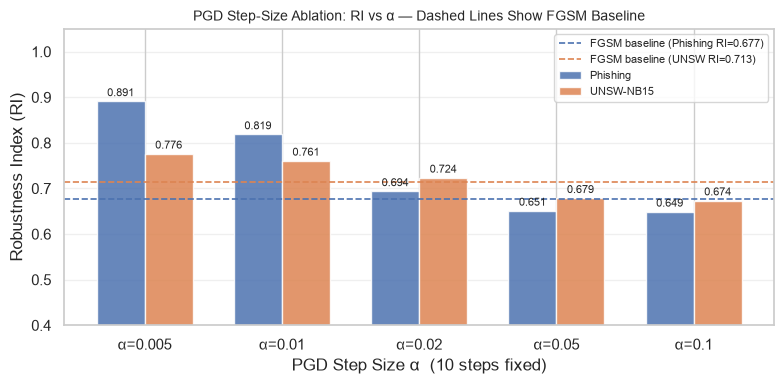

Saved: pgd_alpha_ablation_ri.png


In [16]:
# --- Figure 1: RI vs alpha bar chart (both datasets side by side) ---
labels = [f"α={a}" for a in ALPHA_VALUES]
ri_p = [ri(results_p[f"PGD α={a}"]) for a in ALPHA_VALUES]
ri_u = [ri(results_u[f"PGD α={a}"]) for a in ALPHA_VALUES]
ri_f_p = ri(results_p["FGSM"])
ri_f_u = ri(results_u["FGSM"])

x = np.arange(len(ALPHA_VALUES)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w/2, ri_p, w, label="Phishing",  color="C0", alpha=0.85)
b2 = ax.bar(x + w/2, ri_u, w, label="UNSW-NB15", color="C1", alpha=0.85)
ax.bar_label(b1, fmt="%.3f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.3f", fontsize=8, padding=2)
ax.axhline(ri_f_p, color="C0", linestyle="--", linewidth=1.2,
           label=f"FGSM baseline (Phishing RI={ri_f_p:.3f})")
ax.axhline(ri_f_u, color="C1", linestyle="--", linewidth=1.2,
           label=f"FGSM baseline (UNSW RI={ri_f_u:.3f})")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("PGD Step Size α  (10 steps fixed)")
ax.set_ylabel("Robustness Index (RI)")
ax.set_title("PGD Step-Size Ablation: RI vs α — Dashed Lines Show FGSM Baseline",
             fontsize=10)
ax.legend(fontsize=8); ax.set_ylim(0.4, 1.05); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("pgd_alpha_ablation_ri.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: pgd_alpha_ablation_ri.png")


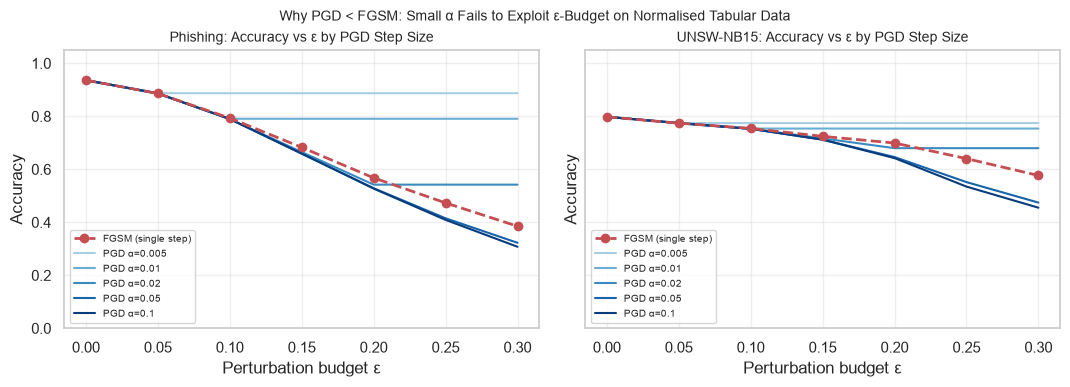

Saved: pgd_alpha_ablation_curves.png


In [17]:
# --- Figure 2: Accuracy curves for selected alphas (Phishing) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, results, title in [
    (axes[0], results_p, "Phishing"),
    (axes[1], results_u, "UNSW-NB15")]:

    colors = plt.cm.Blues(np.linspace(0.35, 0.95, len(ALPHA_VALUES)))
    ax.plot(EPSILONS, results["FGSM"], "r--o", linewidth=2,
            label="FGSM (single step)", zorder=10)
    for alpha, col in zip(ALPHA_VALUES, colors):
        key = f"PGD α={alpha}"
        ax.plot(EPSILONS, results[key], "-", color=col,
                linewidth=1.5, label=f"PGD α={alpha}")

    ax.set_title(f"{title}: Accuracy vs ε by PGD Step Size", fontsize=10)
    ax.set_xlabel("Perturbation budget ε"); ax.set_ylabel("Accuracy")
    ax.legend(fontsize=7.5, loc="lower left"); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

fig.suptitle("Why PGD < FGSM: Small α Fails to Exploit ε-Budget on Normalised Tabular Data",
             fontsize=10)
fig.tight_layout(pad=1.5); fig.subplots_adjust(top=0.88)
plt.savefig("pgd_alpha_ablation_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: pgd_alpha_ablation_curves.png")


In [18]:
# --- Summary table for paper ---
rows = []
for ds, results, ri_f in [
    ("Phishing",  results_p, ri_f_p),
    ("UNSW-NB15", results_u, ri_f_u)]:
    rows.append([ds, "FGSM", "—", round(ri_f, 4)])
    for alpha in ALPHA_VALUES:
        ri_val = ri(results[f"PGD α={alpha}"])
        rows.append([ds, "PGD", alpha, round(ri_val, 4)])

df_tbl = pd.DataFrame(rows, columns=["Dataset","Attack","α","RI"])
print("\n=== ABLATION SUMMARY TABLE ===")
print(df_tbl.to_string(index=False))
df_tbl.to_csv("pgd_ablation_table.csv", index=False)
print("\nSaved: pgd_ablation_table.csv")

# Key finding
print("\n--- Key Finding ---")
for ds, results, ri_f in [
    ("Phishing",  results_p, ri_f_p),
    ("UNSW-NB15", results_u, ri_f_u)]:
    ri_default = ri(results["PGD α=0.01"])
    ri_large   = ri(results[f"PGD α={ALPHA_VALUES[-1]}"])
    print(f"{ds}: FGSM RI={ri_f:.4f}  PGD(α=0.01) RI={ri_default:.4f}"
          f"  PGD(α=0.10) RI={ri_large:.4f}")
    if ri_large < ri_f:
        print(f"  -> Even α=0.10 does not surpass FGSM — confirms structural phenomenon")
    else:
        print(f"  -> Large α closes the gap; α=0.01 underperforms FGSM")



=== ABLATION SUMMARY TABLE ===
  Dataset Attack      α     RI
 Phishing   FGSM      — 0.6771
 Phishing    PGD  0.005 0.8911
 Phishing    PGD   0.01 0.8185
 Phishing    PGD   0.02 0.6938
 Phishing    PGD   0.05 0.6510
 Phishing    PGD    0.1 0.6489
UNSW-NB15   FGSM      — 0.7131
UNSW-NB15    PGD  0.005 0.7762
UNSW-NB15    PGD   0.01 0.7607
UNSW-NB15    PGD   0.02 0.7235
UNSW-NB15    PGD   0.05 0.6787
UNSW-NB15    PGD    0.1 0.6736

Saved: pgd_ablation_table.csv

--- Key Finding ---
Phishing: FGSM RI=0.6771  PGD(α=0.01) RI=0.8185  PGD(α=0.10) RI=0.6489
  -> Even α=0.10 does not surpass FGSM — confirms structural phenomenon
UNSW-NB15: FGSM RI=0.7131  PGD(α=0.01) RI=0.7607  PGD(α=0.10) RI=0.6736
  -> Even α=0.10 does not surpass FGSM — confirms structural phenomenon
